# Relatório Final - Asteroides

## Importações

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PowerTransformer
#from scipy.stats import skew as _skew, kurtosis as _kurt

In [ ]:
ds = pd.read_csv("https://github.com/aland3r/asteroides/releases/download/dataset/asteroids-dataset.csv")

C:\Users\aland\AppData\Local\Temp\ipykernel_5464\4123627387.py:1: DtypeWarning: Columns (0: pdes, 1: name, 2: prefix) have mixed types. Specify dtype option on import or set low_memory=False.
  ds = pd.read_csv("https://github.com/aland3r/asteroids/releases/download/dataset/asteroids.csv")


Os dadataset foi fornecido por um pesquisador de astrofósica através do Kaggle. Trata-se de uma base de dados de asteroides, um tópico que consideramos interessantes para problemas de regressão e classificação. Atualmente, Aprendizagem de Máquina resolve muitos problemas em astronomia e astrofísica.

O dataset foi obtido e oficialmente mantido pelo Laboratório de Propulsão a Jato do Instituto de Tecnologia da California, uma organização sob a NASA.

In [ ]:
ds.shape

(958524, 45)

In [ ]:
ds.columns

Index(['id', 'spkid', 'full_name', 'pdes', 'name', 'prefix', 'neo', 'pha', 'H',
       'diameter', 'albedo', 'diameter_sigma', 'orbit_id', 'epoch',
       'epoch_mjd', 'epoch_cal', 'equinox', 'e', 'a', 'q', 'i', 'om', 'w',
       'ma', 'ad', 'n', 'tp', 'tp_cal', 'per', 'per_y', 'moid', 'moid_ld',
       'sigma_e', 'sigma_a', 'sigma_q', 'sigma_i', 'sigma_om', 'sigma_w',
       'sigma_ma', 'sigma_ad', 'sigma_n', 'sigma_tp', 'sigma_per', 'class',
       'rms'],
      dtype='str')

## Guia de Atributos

**🔑 Identificadores**

- `id`, `spkid` — Números de identificação únicos atribuídos a cada asteroide no banco de dados da NASA. Não possuem valor analítico.

- `full_name`, `pdes`, `name`, `prefix` — Nome e designação oficial do asteroide. A maioria dos asteroides não tem nome — apenas uma designação técnica como "2021 AB3".

- `orbit_id` — Identificador da solução orbital, indica qual versão do cálculo da órbita está sendo usada.

---

**⚠️ Classificação de Risco**

- `neo` — Near-Earth Object: indica se o asteroide é um objeto próximo à Terra (Y/N). Um asteroide é NEO quando sua órbita se aproxima a menos de 1,3 au do Sol.

- `pha` — Potentially Hazardous Asteroid: indica se o asteroide é potencialmente perigoso (Y/N). Um asteroide é PHA quando tem `moid` ≤ 0,05 au E diâmetro ≥ 140 metros. ⭐ Target principal do projeto.

---

**🪨 Características Físicas**

- `H` — Magnitude absoluta: mede o brilho intrínseco do asteroide. Quanto menor o valor, mais brilhante e geralmente maior o objeto. É uma das poucas características físicas disponível para quase todos os asteroides.

- `diameter` — Diâmetro do asteroide em quilômetros. Disponível para apenas ~14% dos asteroides, pois medir o tamanho real requer observações telescópicas detalhadas.

- `albedo` — Refletividade da superfície: o quanto o asteroide reflete a luz solar. Varia de 0 (superfície completamente escura) a 1 (superfície completamente reflexiva). Asteroides rochosos tendem a ter albedo baixo; asteroides metálicos, albedo alto.

- `diameter_sigma` — Incerteza do diâmetro: o erro estimado na medição do diâmetro (em km). Quanto maior, menos precisa foi a medição.

---

**🌌 Parâmetros Orbitais**

- `e` — Excentricidade: o quanto a órbita é alongada. Valores próximos de 0 indicam órbita circular; próximos de 1 indicam órbita muito elíptica, fazendo o asteroide variar muito sua distância do Sol.

- `a` — Semi-eixo maior: o "tamanho médio" da órbita, equivalente à distância média ao Sol (em au). Quanto maior, mais distante do Sol o asteroide orbita.

- `q` — Periélio: a menor distância que o asteroide atinge em relação ao Sol durante sua órbita. Asteroides com periélio pequeno passam muito perto do Sol — e potencialmente perto da Terra.

- `i` — Inclinação: o ângulo entre o plano da órbita do asteroide e o plano da órbita da Terra (eclíptica). Valores próximos de 0° indicam que o asteroide orbita no mesmo plano que a Terra.

- `om` — Longitude do nodo ascendente: o ângulo que indica por onde a órbita do asteroide atravessa o plano da eclíptica de baixo para cima.

- `w` — Argumento do periélio: o ângulo que indica a orientação da órbita dentro do seu plano.

- `ma` — Anomalia média: indica a posição atual do asteroide ao longo de sua órbita, como se ele se movesse em velocidade constante.

- `ad` — Afélio: a maior distância que o asteroide atinge em relação ao Sol durante sua órbita — o oposto do periélio.

- `n` — Movimento médio: a velocidade angular média do asteroide em sua órbita (graus por dia). Asteroides mais próximos do Sol se movem mais rápido.

- `per` — Período orbital: o tempo que o asteroide leva para completar uma volta ao redor do Sol, em dias.

- `per_y` — Período orbital em anos: o mesmo que `per`, mas expresso em anos.

- `tp`, `tp_cal` — Tempo de passagem pelo periélio: a data em que o asteroide passou (ou passará) pelo ponto mais próximo do Sol.

---

**🌍 Proximidade com a Terra**

- `moid` — Distância mínima de intersecção orbital: a menor distância possível entre a órbita do asteroide e a órbita da Terra, em au. Valores abaixo de 0,05 au são considerados de risco.

- `moid_ld` — O mesmo que `moid`, mas em distâncias lunares (1 distância lunar ≈ 384.400 km). Facilita a intuição sobre o quão perto o asteroide pode chegar da Terra.

---

**🔭 Classe Orbital**

- `class` — Categoria que descreve a localização e o comportamento da órbita do asteroide no sistema solar:
  - `MBA` — Main Belt: cinturão principal entre Marte e Júpiter (maioria dos asteroides)
  - `IMB` / `OMB` — Cinturão interno e externo
  - `MCA` — Mars Crossing: cruza a órbita de Marte
  - `APO` — Apollo: cruza a órbita da Terra, semi-eixo > 1 au
  - `ATE` — Aten: cruza a órbita da Terra, semi-eixo < 1 au
  - `AMO` — Amor: aproxima-se da Terra mas não cruza
  - `IEO` — Interior Earth Object: órbita inteiramente dentro da Terra
  - `TJN` — Jupiter Trojan: compartilha órbita com Júpiter
  - `TNO` — Trans-Neptunian: além de Netuno
  - `CEN` — Centaur: entre Júpiter e Netuno
  - `HYA` — Hyperbolic: passa uma única vez pelo sistema solar

---

**📅 Época/Referencial**

- `epoch`, `epoch_mjd`, `epoch_cal` — A data de referência em que os parâmetros orbitais foram calculados. Órbitas mudam com o tempo devido à gravidade de outros planetas, então é importante saber quando a medição foi feita.

- `equinox` — O referencial astronômico usado para medir os ângulos orbitais (geralmente J2000).

---

**📏 Incertezas Orbitais**

- `sigma_e`, `sigma_a`, `sigma_q`, `sigma_i`, `sigma_om`, `sigma_w`, `sigma_ma`, `sigma_ad`, `sigma_n`, `sigma_tp`, `sigma_per` — Erros estimados (1-sigma) de cada parâmetro orbital. Indicam a precisão da solução orbital. Quanto menor, mais confiável a medição.

---

**✅ Qualidade da Solução Orbital**

- `rms` — Erro RMS (Root Mean Square) da solução orbital: mede o quão bem a órbita calculada se ajusta às observações reais. Valores menores indicam uma solução orbital mais precisa e confiável.

In [ ]:
ds['class'].value_counts()

class
MBA    855954
OMB     28355
IMB     20360
MCA     18685
APO     12687
AMO      8457
TJN      8221
TNO      3468
ATE      1729
CEN       506
AST        76
IEO        22
HYA         4
Name: count, dtype: int64

In [ ]:
ds['pha'].value_counts()

pha
N    936537
Y      2066
Name: count, dtype: int64

In [ ]:
bc = PowerTransformer(method='box-cox')
ds['diameter_bc'] = bc.fit_transform(np.array(ds['diameter']).reshape(-1, 1))


## Objetivos

- Construir um modelo de Machine Learning capaz de classificar se um asteroide é 
potencialmente perigoso (`pha`), utilizando suas características físicas e orbitais, 
de forma que generalize bem para asteroides ainda não classificados.

  - Realizar uma análise exploratória para identificar quais características físicas 
  e orbitais diferenciam asteroides potencialmente perigosos dos demais.
  
  - Investigar o impacto do desbalanceamento extremo de classes (0,2% PHA) e avaliar 
  estratégias de balanceamento para a etapa de modelagem.
  
  - Comparar modelos com e sem a variável `moid_ld`, dado que ela está diretamente 
  na definição de PHA, avaliando se os parâmetros orbitais por si só são suficientes 
  para classificar asteroides perigosos.

## Hipóteses

**Proximidade com a Terra**
- H1: Asteroides PHA apresentam `moid_ld` significativamente menor que não-PHAs
- H2: Asteroides NEO têm maior proporção de PHAs que não-NEOs

**Características Físicas**
- H3: Asteroides PHA tendem a ter maior diâmetro
- H4: A magnitude absoluta `H` é menor em PHAs (objetos maiores/mais brilhantes)

**Parâmetros Orbitais**
- H5: PHAs apresentam maior excentricidade `e` (órbitas mais elípticas)
- H6: PHAs tendem a ter menor semi-eixo maior `a`
- H7: PHAs apresentam menor distância do periélio `q`
- H8: A inclinação orbital `i` é menor em PHAs

In [ ]:
ds['neo'].value_counts()

neo
N    935625
Y     22895
Name: count, dtype: int64

In [ ]:
print(ds['moid_ld'].describe())

count    958397.000000
mean        539.364207
std         834.306975
min           0.000000
25%         375.394939
50%         477.706175
75%         617.324804
max       30929.908422
Name: moid_ld, dtype: float64


In [ ]:
ds.isnull().sum()

id                     0
spkid                  0
full_name              0
pdes                   0
name              936460
prefix            958506
neo                    4
pha                19921
H                   6263
diameter          822315
albedo            823421
diameter_sigma    822443
orbit_id               0
epoch                  0
epoch_mjd              0
epoch_cal              0
equinox                0
e                      0
a                      0
q                      0
i                      0
om                     0
w                      0
ma                     1
ad                     4
n                      0
tp                     0
tp_cal                 0
per                    4
per_y                  1
moid               19921
moid_ld              127
sigma_e            19922
sigma_a            19922
sigma_q            19922
sigma_i            19922
sigma_om           19922
sigma_w            19922
sigma_ma           19922
sigma_ad           19926


In [ ]:
# ver todas de uma vez
ds.isnull().sum().sort_values(ascending=False)

prefix            958506
name              936460
albedo            823421
diameter_sigma    822443
diameter          822315
sigma_per          19926
sigma_ad           19926
sigma_om           19922
sigma_ma           19922
sigma_q            19922
sigma_a            19922
sigma_w            19922
sigma_i            19922
sigma_tp           19922
sigma_e            19922
sigma_n            19922
moid               19921
pha                19921
H                   6263
moid_ld              127
neo                    4
ad                     4
per                    4
rms                    2
per_y                  1
ma                     1
id                     0
full_name              0
pdes                   0
orbit_id               0
spkid                  0
tp_cal                 0
om                     0
w                      0
tp                     0
n                      0
i                      0
equinox                0
epoch_cal              0
epoch_mjd              0


## Hipóteses

**Proximidade com a Terra**
1. Os asteroides mais próximos da terra tendem a representar maior risco, de forma que as instâncias sinalizadas com PHA apresentam `moid_ld` significativamente menor do que `pha = N`.
2. Os asteroides com registros de NEO (Next Earth Object) têm maior proporção de PHAs do que os asteroides não-NEO.

**Características físicas**
3. Asteroides PHA tendem a ter maior diâmetro.
4. Asteroides potencialmente perigosos apresentam menor albedo (superfície mais escura)

## Descrição Estatística



## Análise de Dados univariados

#### **1. Qual é a proporção de asteroides potencialmente perigosos?**

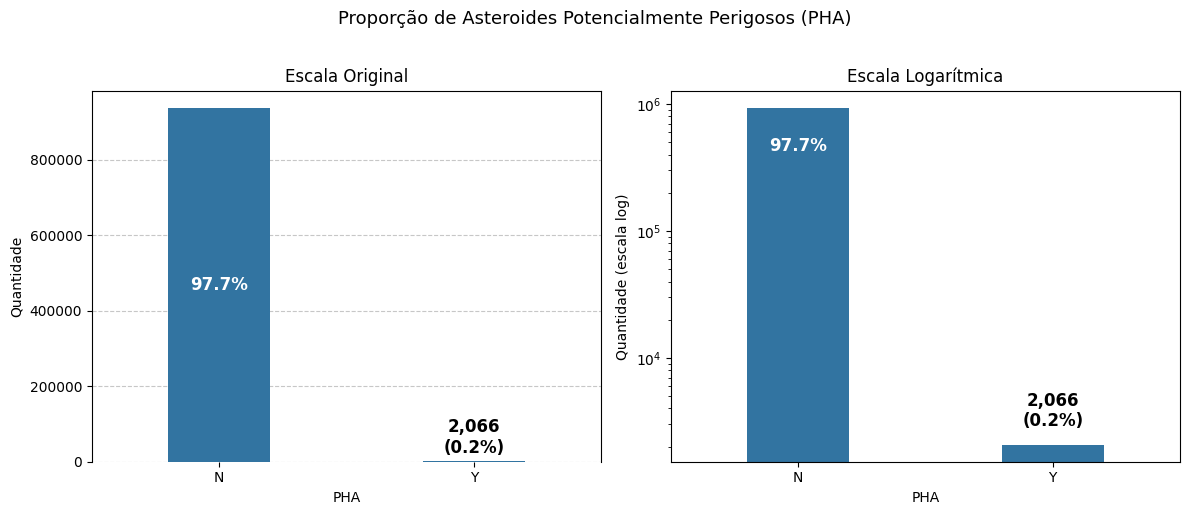

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Proporção de Asteroides Potencialmente Perigosos (PHA)', 
             fontsize=13, y=1.02)

contagem = ds['pha'].value_counts()

for ax, log in zip(axes, [False, True]):
    sns.barplot(x=contagem.index, y=contagem.values, ax=ax, width=0.4)
    
    if log:
        ax.set_yscale('log')
        ax.set_title('Escala Logarítmica')
        ax.set_ylabel('Quantidade (escala log)')
    else:
        ax.set_title('Escala Original')
        ax.set_ylabel('Quantidade')
        # remove linha inferior
        ax.spines['bottom'].set_visible(False)
        # grid horizontal pontilhado
        ax.yaxis.grid(True, linestyle='--', alpha=0.7)
        ax.set_axisbelow(True)
    
    ax.set_xlabel('PHA')
    
    for i, (label, v) in enumerate(zip(contagem.index, contagem.values)):
        pct = v / len(ds) * 100
        if label == 'N':
            ax.text(i, v / 2, f'{pct:.1f}%',
                    ha='center', va='center',
                    fontsize=12, fontweight='bold', color='white')
        else:
            y_pos = v * 1.3 if log else v + 10000
            ax.text(i, y_pos, f'{v:,}\n({pct:.1f}%)',
                    ha='center', va='bottom',
                    fontsize=12, fontweight='bold', color='black')

plt.tight_layout()
plt.show()

Percebe-se um desbalanciamento extremo entre as classes. Apenas 0,2% dos asteroides (2.066) são classificados como potencialmente perigosos, contra 97,7% (936.537) não perigosos. Torna-se evidente que precisaremos utilizar técnicas de balanceamento de classes como oversampling ou undersampling na etapa de preprocessamento, e métricas como acurácia isolada não serão suficientes para avaliar o modelo. Será necessário considerar métricas como o F1-score, precisão e recall.

---

#### **2. Qual a proporção de asteroides próximos à Terra?**

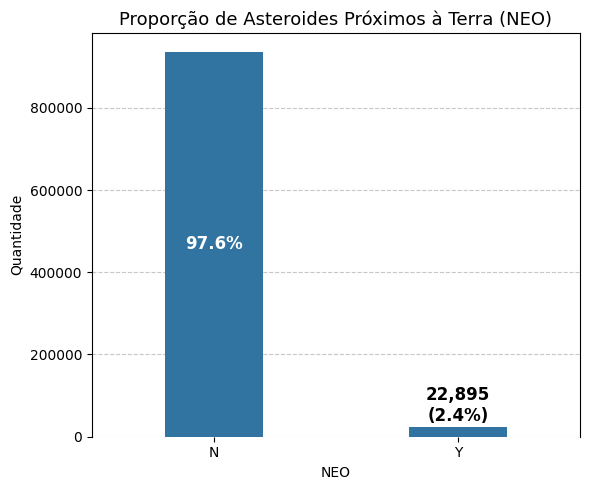

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))

contagem = ds['neo'].value_counts()

sns.barplot(x=contagem.index, y=contagem.values, ax=ax, width=0.4)

ax.set_title('Proporção de Asteroides Próximos à Terra (NEO)', fontsize=13)
ax.set_xlabel('NEO')
ax.set_ylabel('Quantidade')
ax.spines['bottom'].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

for i, (label, v) in enumerate(zip(contagem.index, contagem.values)):
    pct = v / len(ds) * 100
    if label == 'N':
        ax.text(i, v / 2, f'{pct:.1f}%',
                ha='center', va='center',
                fontsize=12, fontweight='bold', color='white')
    else:
        ax.text(i, v + 5000, f'{v:,}\n({pct:.1f}%)',
                ha='center', va='bottom',
                fontsize=12, fontweight='bold', color='black')

plt.tight_layout()
plt.show()

Apenas 2,4% dos asteroides (22.895) são NEOs, refletindo a dominância do cinturão principal no sistema solar. Embora minoritários, os NEOs são centrais para o projeto — todo PHA é necessariamente um NEO, o que motivou a decisão de filtrar o dataset para esse subconjunto na etapa de modelagem, reduzindo de 958.524 para 22.895 instâncias e tornando o problema mais tratável.O dataset apresenta forte desbalanceamento na variável neo — apenas 2,4% dos asteroides (22.895) são classificados como objetos próximos à Terra, contra 97,6% (935.625) que orbitam longe. Esse resultado reflete a composição real do sistema solar, onde a grande maioria dos asteroides catalogados pertence ao cinturão principal entre Marte e Júpiter. Embora minoritários, os NEOs são centrais para o objetivo do projeto — todo asteroide potencialmente perigoso (PHA) é necessariamente um NEO, mas nem todo NEO é um PHA. Essa relação motivou a decisão de filtrar o dataset para o subconjunto NEO na etapa de modelagem, reduzindo de 958.524 para 22.895 instâncias e tornando o problema de classificação mais tratável.

### **3. "Qual é a distribuição das classes orbitais no dataset e como isso se relaciona com a classificação de risco?**

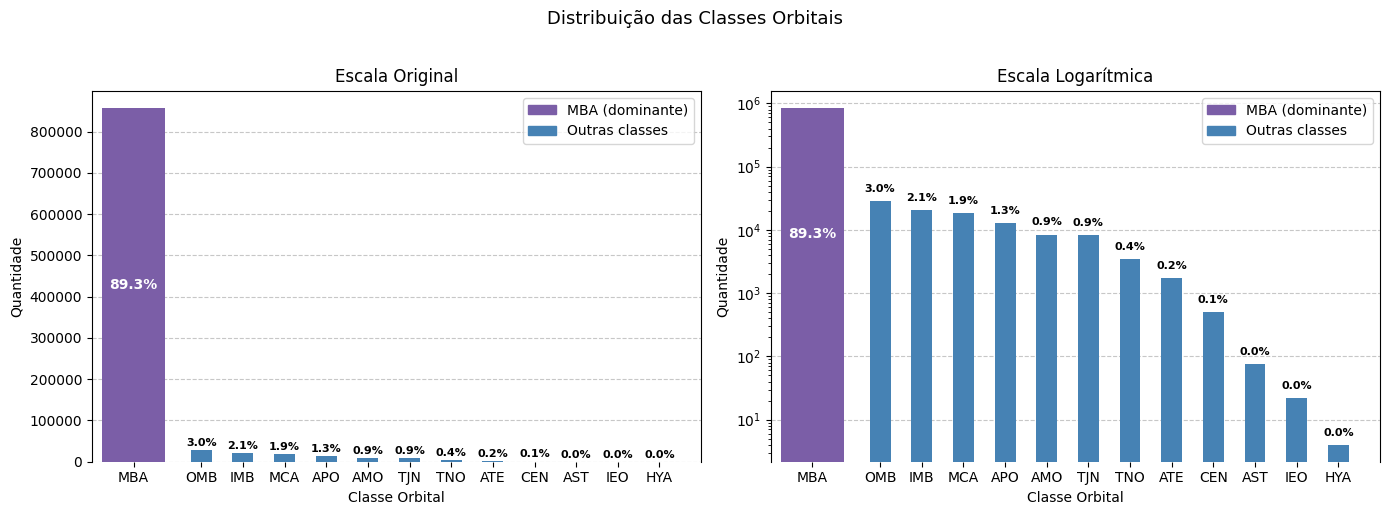

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribuição das Classes Orbitais', fontsize=13, y=1.02)

contagem = ds['class'].value_counts()
labels = list(contagem.index)
values = list(contagem.values)
n = len(labels)

# configurações de espaçamento
espacamento = 0.8   # distância entre barras azuis
offset_mba  = 0.5  # gap extra entre MBA e OMB

# calcular posições
posicoes = []
for i, label in enumerate(labels):
    if i == 0:  # MBA
        posicoes.append(0)
    else:
        posicoes.append(offset_mba + i * espacamento)

for ax, log in zip(axes, [False, True]):
    for pos, label, v in zip(posicoes, labels, values):
        if label == 'MBA':
            cor = '#7B5EA7'
            larg = 1.2
        else:
            cor = 'steelblue'
            larg = 0.4
        ax.bar(pos, v, width=larg, color=cor)

    ax.set_xticks(posicoes)
    ax.set_xticklabels(labels)
    ax.set_xlim(-0.8, posicoes[-1] + 0.8)
    ax.set_xlabel('Classe Orbital')
    ax.set_ylabel('Quantidade')
    ax.spines['bottom'].set_visible(False)
    ax.yaxis.grid(True, linestyle='--', alpha=0.7)
    ax.set_axisbelow(True)

    if log:
        ax.set_yscale('log')
        ax.set_title('Escala Logarítmica')
    else:
        ax.set_title('Escala Original')

    for pos, label, v in zip(posicoes, labels, values):
        pct = v / len(ds) * 100
        if label == 'MBA':
            y_pos = v / 2 if not log else v * 0.01
            ax.text(pos, y_pos, f'{pct:.1f}%',
                    ha='center', va='center',
                    fontsize=10, fontweight='bold', color='white')
        else:
            y_pos = v * 1.3 if log else v + 5000
            ax.text(pos, y_pos, f'{pct:.1f}%',
                    ha='center', va='bottom',
                    fontsize=8, fontweight='bold', color='black')

from matplotlib.patches import Patch
for ax in axes:
    ax.legend(handles=[Patch(color='#7B5EA7', label='MBA (dominante)'),
                       Patch(color='steelblue', label='Outras classes')],
              loc='upper right')

plt.tight_layout()
plt.show()

O dataset é amplamente dominado por asteroides do cinturão principal (MBA), que representam 89,3% das instâncias. A escala logarítmica revela que as demais classes, apesar de numericamente minoritárias, são igualmente importantes para o objetivo do projeto. Em particular, as classes APO, ATE, AMO e IEO — coletivamente conhecidas como NEOs — são as únicas cujas órbitas se aproximam ou cruzam a órbita da Terra, sendo portanto os únicos candidatos reais à classificação PHA. Essa concentração de PHAs nas classes NEO motiva a decisão de filtrar o dataset para essas classes na etapa de modelagem, reduzindo de 958.524 para 22.895 instâncias e aumentando a proporção de PHAs de 0,2% para 9%, tornando o problema de classificação mais tratável.

---

#### **4. A váriavel `diameter` possui muitos valores ausentes?**

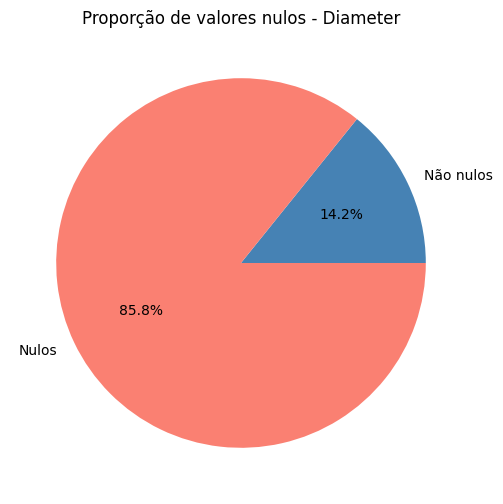

In [ ]:
# contar nulos e não nulos
null = ds['diameter'].isnull().sum()
notnull = ds['diameter'].notnull().sum()

# gráfico de pizza
plt.figure(figsize=(6, 6))
plt.pie([notnull, null], 
        labels=['Não nulos', 'Nulos'],
        autopct='%1.1f%%',
        colors=['steelblue', 'salmon'])
plt.title('Proporção de valores nulos - Diameter')
plt.show()

85,8% dos valores de diameter estão ausentes, o que é esperado dado o contexto do dataset. Medir o diâmetro real de um asteroide requer observações telescópicas detalhadas, que não estão disponíveis para a maioria dos objetos catalogados. Isso implica que as análises envolvendo essa variável representam apenas uma fração dos asteroides e que, na etapa de preprocessamento, será necessário definir uma estratégia de tratamento — como imputação ou remoção da coluna — antes de utilizá-la como feature no modelo.

---

#### **5. A variável `moid_ld` apresenta outliers significativos dentro do subconjunto NEO?**

In [ ]:
Q1 = ds_neo['moid_ld'].quantile(0.25)
Q3 = ds_neo['moid_ld'].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers = ds_neo[(ds_neo['moid_ld'] < limite_inferior) | 
                  (ds_neo['moid_ld'] > limite_superior)]

print(f"Q1: {Q1:.2f}")
print(f"Q3: {Q3:.2f}")
print(f"IQR: {IQR:.2f}")
print(f"Limite inferior: {limite_inferior:.2f}")
print(f"Limite superior: {limite_superior:.2f}")
print(f"Outliers: {len(outliers)} ({len(outliers)/len(ds_neo)*100:.1f}%)")

Q1: 6.09
Q3: 55.51
IQR: 49.42
Limite inferior: -68.05
Limite superior: 129.64
Outliers: 710 (3.1%)


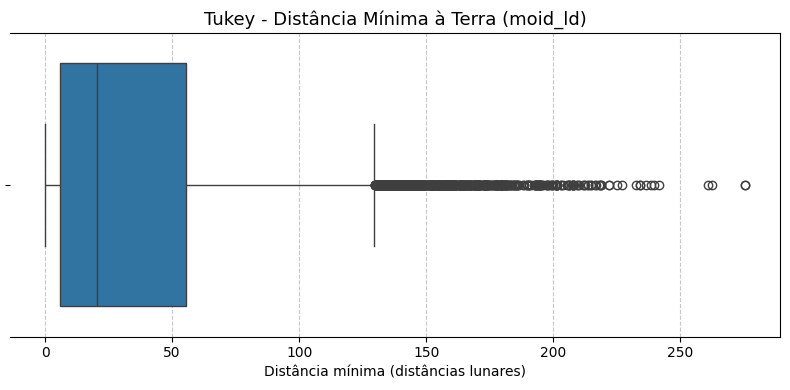

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))

sns.boxplot(x=ds_neo['moid_ld'], ax=ax)

ax.set_title('Tukey - Distância Mínima à Terra (moid_ld)', fontsize=13)
ax.set_xlabel('Distância mínima (distâncias lunares)')
ax.spines['left'].set_visible(False)
ax.xaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

In [ ]:
nulos = ds_neo['diameter'].isnull().sum()
total = len(ds_neo)
print(f"Nulos: {nulos} ({nulos/total*100:.1f}%)")

Nulos: 22046 (96.3%)


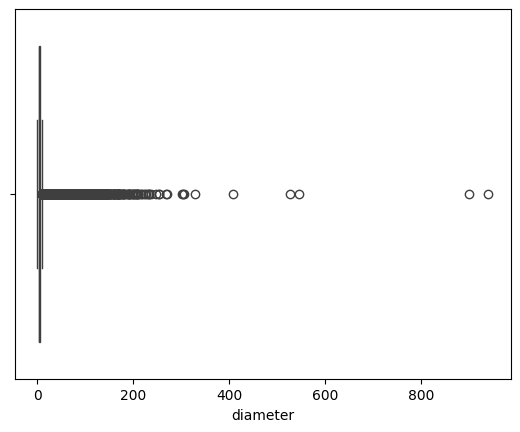

In [ ]:
sns.boxplot(x=ds['diameter'])
plt.show()

In [ ]:

# proporção de PHA
ds['pha'].value_counts()

pha
N    936537
Y      2066
Name: count, dtype: int64

In [ ]:
# proporção de NEO
ds['neo'].value_counts()

neo
N    935625
Y     22895
Name: count, dtype: int64

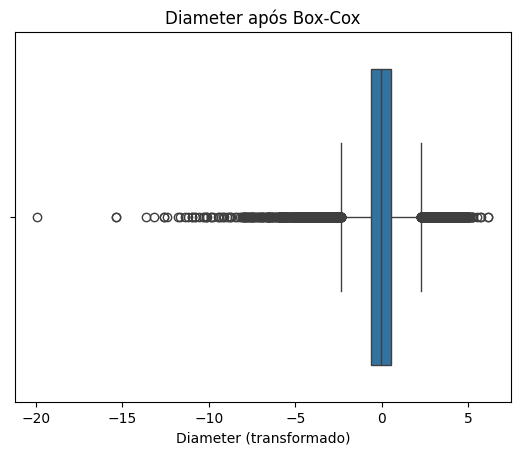

In [ ]:
sns.boxplot(x=ds['diameter_bc'])
plt.title('Diameter após Box-Cox')
plt.xlabel('Diameter (transformado)')
plt.show()

In [ ]:
# filtrar só os NEOs
neo_classes = ['APO', 'ATE', 'AMO', 'IEO']
ds_neo = ds[ds['class'].isin(neo_classes)]

print(f"Total de asteroides: {len(ds)}")
print(f"Total de NEOs: {len(ds_neo)}")
print(f"Proporção: {len(ds_neo)/len(ds)*100:.1f}%")

# ver proporção de PHA dentro dos NEOs
print("\nPHA dentro dos NEOs:")
print(ds_neo['pha'].value_counts())
print(ds_neo['pha'].value_counts(normalize=True) * 100)

Total de asteroides: 958524
Total de NEOs: 22895
Proporção: 2.4%

PHA dentro dos NEOs:
pha
N    20828
Y     2066
Name: count, dtype: int64
pha
N    90.975802
Y     9.024198
Name: proportion, dtype: float64
